<a href="https://colab.research.google.com/github/asrianda/jurnal/blob/main/GIS_K_Means%2B%2B_Modifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal clusters (Modified): 7
Silhouette Score (Modified): 0.6475060845923745
Silhouette Score (Standard): 0.6353463144142495

Cluster distribution (Modified):
cluster_mod
0    1246
5    1039
4     418
1      27
6       9
2       8
3       1
Name: count, dtype: int64

Cluster distribution (Standard):
cluster_std
0    1246
3    1055
6     415
4      20
2       8
5       3
1       1
Name: count, dtype: int64

Comparison of Standard vs Modified:
cluster_mod     0   1  2  3    4     5  6
cluster_std                              
0            1246   0  0  0    0     0  0
1               0   0  0  1    0     0  0
2               0   0  5  0    3     0  0
3               0  16  0  0    0  1039  0
4               0  11  0  0    0     0  9
5               0   0  3  0    0     0  0
6               0   0  0  0  415     0  0


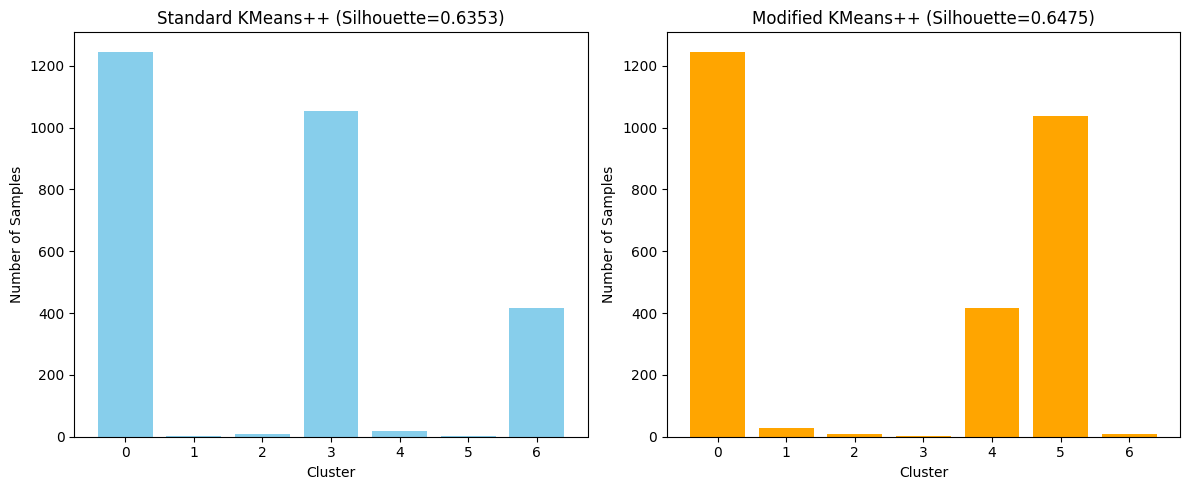

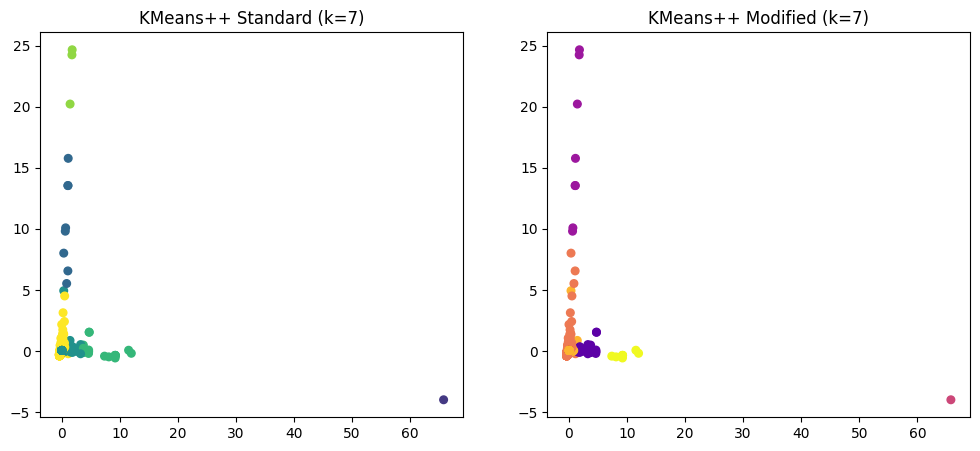

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans

# =====================================================
# KMeans++ Modified
# =====================================================
class KMeansPlusPlusModified:
    def __init__(self, p=2, max_iter=100, tol=1e-4, random_state=None):
        self.p = p
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None

    def _initialize_centroids(self, X, k):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        centroids = [X[np.random.randint(0, n_samples)]]

        while len(centroids) < k:
            D = np.min(cdist(X, np.array(centroids)), axis=1)
            total = np.sum(D ** self.p)
            if total == 0:
                idx_next = np.random.randint(0, n_samples)
            else:
                prob = (len(X) * (D ** self.p)) / total
                if prob.sum() == 0 or np.any(np.isnan(prob)):
                    idx_next = np.random.randint(0, n_samples)
                else:
                    prob = prob / prob.sum()
                    idx_next = np.random.choice(n_samples, p=prob)
            centroids.append(X[idx_next])
        return np.array(centroids)

    def _assign_clusters(self, X, centroids):
        distances = cdist(X, centroids)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels, k):
        centroids = np.zeros((k, X.shape[1]))
        for j in range(k):
            cluster_points = X[labels == j]
            if len(cluster_points) == 0:
                centroids[j] = X[np.random.randint(0, X.shape[0])]
            else:
                centroids[j] = cluster_points.mean(axis=0)
        return centroids

    def fit(self, X, k):
        self.centroids = self._initialize_centroids(X, k)
        for _ in range(self.max_iter):
            labels = self._assign_clusters(X, self.centroids)
            new_centroids = self._update_centroids(X, labels, k)
            if np.allclose(self.centroids, new_centroids, atol=self.tol):
                break
            self.centroids = new_centroids
        self.labels_ = self._assign_clusters(X, self.centroids)
        return self

    def predict(self, X):
        return self._assign_clusters(X, self.centroids)


# =====================================================
# Fast Silhouette Score (with sampling)
# =====================================================
def fast_silhouette(X, labels, sample_size=1000, random_state=42):
    if X.shape[0] > sample_size:
        X_sample, labels_sample = resample(X, labels, n_samples=sample_size, random_state=random_state)
    else:
        X_sample, labels_sample = X, labels
    return silhouette_score(X_sample, labels_sample)


# =====================================================
# Find best k
# =====================================================
def find_best_k(X, k_min=3, k_max=10, p=2, max_iter=100, tol=1e-4, random_state=42):
    k_max = min(k_max, len(X) - 1)
    best_score = -1
    best_k = k_min
    best_labels = None
    best_centroids = None

    for k in range(k_min, k_max + 1):
        kmeans = KMeansPlusPlusModified(p=p, max_iter=max_iter, tol=tol, random_state=random_state)
        kmeans.fit(X, k)
        labels = kmeans.labels_
        if len(np.unique(labels)) < 2:
            continue
        score = fast_silhouette(X, labels)
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
            best_centroids = kmeans.centroids

    if best_labels is None:
        best_k = k_min
        kmeans = KMeansPlusPlusModified(p=p, max_iter=max_iter, tol=tol, random_state=random_state)
        kmeans.fit(X, best_k)
        best_labels = kmeans.labels_
        best_centroids = kmeans.centroids
        best_score = fast_silhouette(X, best_labels)

    return best_k, best_labels, best_centroids, best_score


# =====================================================
# Example Usage
# =====================================================
if __name__ == "__main__":
    # Load dataset
    df = pd.read_excel("Data_UMKM_LSM_2021.xlsx")
    df = df.dropna(subset=['Jenis_Usaha', 'Tenaga_Kerja', 'Asset', 'Omzet'])

    # Encode categorical feature
    le = LabelEncoder()
    df['Jenis_Usaha_encoded'] = le.fit_transform(df['Jenis_Usaha'])

    # Features
    features = ['Jenis_Usaha_encoded', 'Tenaga_Kerja', 'Asset', 'Omzet']
    X = df[features].values

    # Normalize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Modified KMeans++
    best_k, labels_mod, centroids_mod, score_mod = find_best_k(X_scaled, k_min=3, k_max=8, p=2)
    print("Optimal clusters (Modified):", best_k)
    print("Silhouette Score (Modified):", score_mod)
    df['cluster_mod'] = labels_mod

    # Standard KMeans++
    kmeans_std = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10, max_iter=100)
    labels_std = kmeans_std.fit_predict(X_scaled)
    df['cluster_std'] = labels_std
    score_std = fast_silhouette(X_scaled, labels_std)
    print("Silhouette Score (Standard):", score_std)

    # Cluster distribution tables
    print("\nCluster distribution (Modified):")
    print(df['cluster_mod'].value_counts())
    print("\nCluster distribution (Standard):")
    print(df['cluster_std'].value_counts())

    # Cluster comparison table
    comparison = pd.crosstab(df['cluster_std'], df['cluster_mod'])
    print("\nComparison of Standard vs Modified:")
    print(comparison)

    # =====================================================
    # Visualization: Bar Charts
    # =====================================================
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Standard
    counts_std = df['cluster_std'].value_counts().sort_index()
    axes[0].bar(counts_std.index.astype(str), counts_std.values, color='skyblue')
    axes[0].set_title(f"Standard KMeans++ (Silhouette={score_std:.4f})")
    axes[0].set_xlabel("Cluster")
    axes[0].set_ylabel("Number of Samples")

    # Modified
    counts_mod = df['cluster_mod'].value_counts().sort_index()
    axes[1].bar(counts_mod.index.astype(str), counts_mod.values, color='orange')
    axes[1].set_title(f"Modified KMeans++ (Silhouette={score_mod:.4f})")
    axes[1].set_xlabel("Cluster")
    axes[1].set_ylabel("Number of Samples")

    plt.tight_layout()
    plt.show()

    # =====================================================
    # Visualization: PCA 2D
    # =====================================================
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_std, cmap='viridis', s=30)
    axes[0].set_title(f"KMeans++ Standard (k={best_k})")

    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_mod, cmap='plasma', s=30)
    axes[1].set_title(f"KMeans++ Modified (k={best_k})")

    plt.show()

    # Save results
    df.to_excel("Data_UMKM_Clustered_Modified.xlsx", index=False)


Jumlah baris shapefile: 69
Jumlah baris Excel: 2748
Jumlah hasil merge: 2748


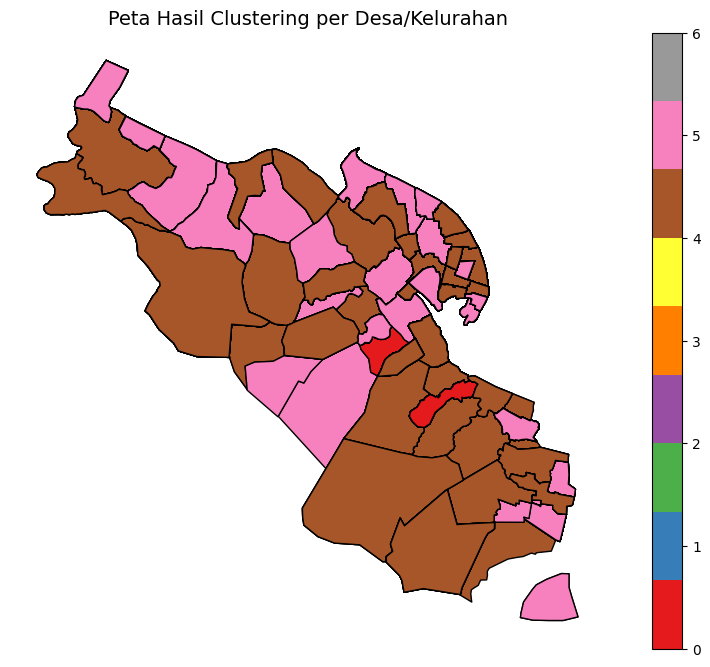

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

data1=pd.read_excel('Data_UMKM_Clustered_Modified.xlsx')
data1.head()
# 1. Baca shapefile (dalam bentuk ZIP atau folder biasa)
gdf1 = gpd.read_file("zip://LSM.zip")
gdf1["DESA"] = gdf1["DESA"].str.strip().str.upper()
data1["Desa"] = data1["Desa"].str.strip().str.upper()
gdf_merged1 = gdf1.merge(data1, how="left", left_on="DESA", right_on="Desa")
gdf_merged1.head()

#-- Tampilkan Datanya
print("Jumlah baris shapefile:", len(gdf1))
print("Jumlah baris Excel:", len(data1))
print("Jumlah hasil merge:", gdf_merged1["cluster_mod"].notna().sum())

# 4. Plot peta dengan warna berdasarkan cluster
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf_merged1.plot(column="cluster_mod", cmap="Set1", legend=True, ax=ax, edgecolor="black")

# 5. Tambahkan judul
plt.title("Peta Hasil Clustering per Desa/Kelurahan", fontsize=14)
plt.axis("off")
plt.show()

In [ ]:
import geopandas as gpd
import pandas as pd

# Baca shapefile dan Excel
gdf1 = gpd.read_file("zip://LSM.zip")
data1 = pd.read_excel("Data_UMKM_Clustered_Modified.xlsx")  # ganti sesuai nama file Excel Anda

# Normalisasi nama desa supaya lebih mudah dicocokkan
gdf1["DESA_norm"] = gdf1["DESA"].str.strip().str.upper()
data1["Desa_norm"] = data1["Desa"].str.strip().str.upper()

# Merge menggunakan kolom normalisasi
gdf_merged1 = gdf1.merge(data1, how="left", left_on="DESA_norm", right_on="Desa_norm")

# Cek desa di shapefile yang tidak punya pasangan di Excel
desa_tidak_match = gdf_merged1[gdf_merged1["cluster_mod"].isna()]["DESA"].unique()

print("Jumlah desa tidak match:", len(desa_tidak_match))
print("Contoh desa tidak match:", desa_tidak_match[:20])  # tampilkan 20 pertama


Jumlah desa tidak match: 4
Contoh desa tidak match: ['JAMBO TIMU' 'BLANG TEUE' 'ASAN KAREUNG' 'INDUSTRI???']


Jumlah baris shapefile: 69
Jumlah baris Excel: 2748
Jumlah hasil merge (punya cluster): 2748


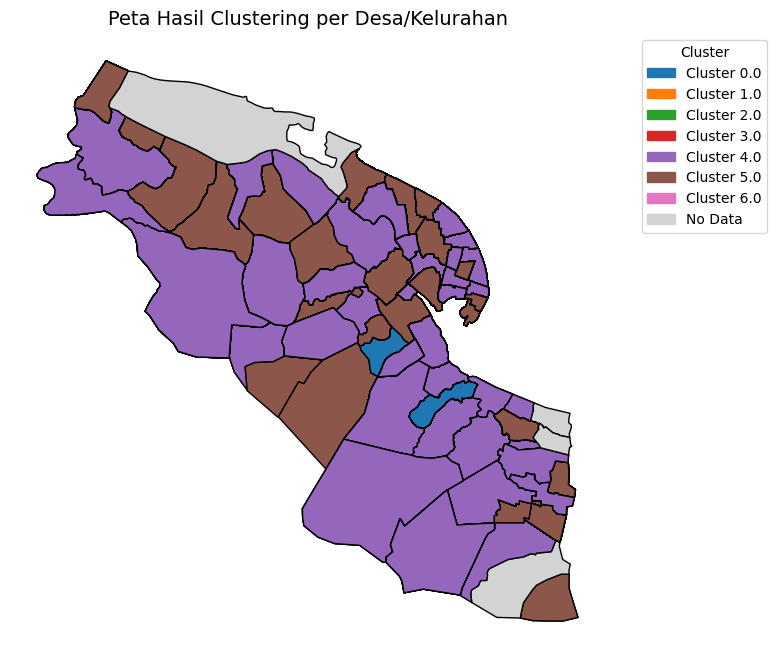

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# =============================
# 0. Baca data cluster
# =============================
# Pastikan file Excel/CSV memiliki kolom 'Desa' dan 'cluster_mod'
data1 = pd.read_excel("Data_UMKM_Clustered_Modified.xlsx")

# =============================
# 1. Baca shapefile
# =============================
gdf1 = gpd.read_file("zip://LSM.zip")

# =============================
# 2. Samakan format nama desa agar konsisten
# =============================
gdf1["DESA"] = gdf1["DESA"].str.strip().str.upper()
data1["Desa"] = data1["Desa"].str.strip().str.upper()

# =============================
# 3. Merge shapefile dengan data cluster
# =============================
gdf_merged1 = gdf1.merge(data1, how="left", left_on="DESA", right_on="Desa")

# =============================
# 4. Info jumlah data
# =============================
print("Jumlah baris shapefile:", len(gdf1))
print("Jumlah baris Excel:", len(data1))
print("Jumlah hasil merge (punya cluster):", gdf_merged1["cluster_mod"].notna().sum())

# =============================
# 5. Pastikan cluster_mod bertipe kategori
# =============================
gdf_merged1["cluster_mod"] = gdf_merged1["cluster_mod"].astype("category")

# =============================
# 6. Buat kolom warna (string biasa, bukan kategori)
# =============================
unique_clusters = gdf_merged1["cluster_mod"].cat.categories
colors = list(mcolors.TABLEAU_COLORS.values())  # ambil warna bawaan matplotlib
color_map = {cluster: colors[i % len(colors)] for i, cluster in enumerate(unique_clusters)}

# Map cluster ke warna
gdf_merged1["color"] = gdf_merged1["cluster_mod"].map(color_map)

# Pastikan kolom color bertipe object (string) agar fillna bisa jalan
gdf_merged1["color"] = gdf_merged1["color"].astype(object)

# Isi nilai NaN dengan warna default
gdf_merged1["color"] = gdf_merged1["color"].fillna("lightgrey")

# =============================
# 7. Plot peta
# =============================
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf_merged1.plot(
    color=gdf_merged1["color"],
    edgecolor="black",
    ax=ax
)

# =============================
# 8. Buat legend manual
# =============================
legend_patches = [mpatches.Patch(color=color_map[c], label=f"Cluster {c}") for c in unique_clusters]
legend_patches.append(mpatches.Patch(color="lightgrey", label="No Data"))
plt.legend(handles=legend_patches, title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# =============================
# 9. Tambahkan judul
# =============================
plt.title("Peta Hasil Clustering per Desa/Kelurahan", fontsize=14)
plt.axis("off")
plt.show()


Menyimpan Peta yang termerge

Jumlah baris shapefile: 69
Jumlah baris Excel: 2748
Jumlah hasil merge (punya cluster): 2748

Baris shapefile yang cluster_mod-nya NaN:
              DESA  cluster_mod
2542    JAMBO TIMU          NaN
2548    BLANG TEUE          NaN
2549  ASAN KAREUNG          NaN
2751   INDUSTRI???          NaN

Baris Excel yang tidak ter-merge ke shapefile:
Empty DataFrame
Columns: [No, Sektor_Perdagangan, Mikro, Kecil, Menengah, Desa, Kecamatan, Jenis_Usaha, Tenaga_Kerja, Asset, Omzet, Jenis_Usaha_encoded, cluster_mod, cluster_std]
Index: []

Hasil desa yang tidak merge telah disimpan ke 'hasil_merge.xlsx'


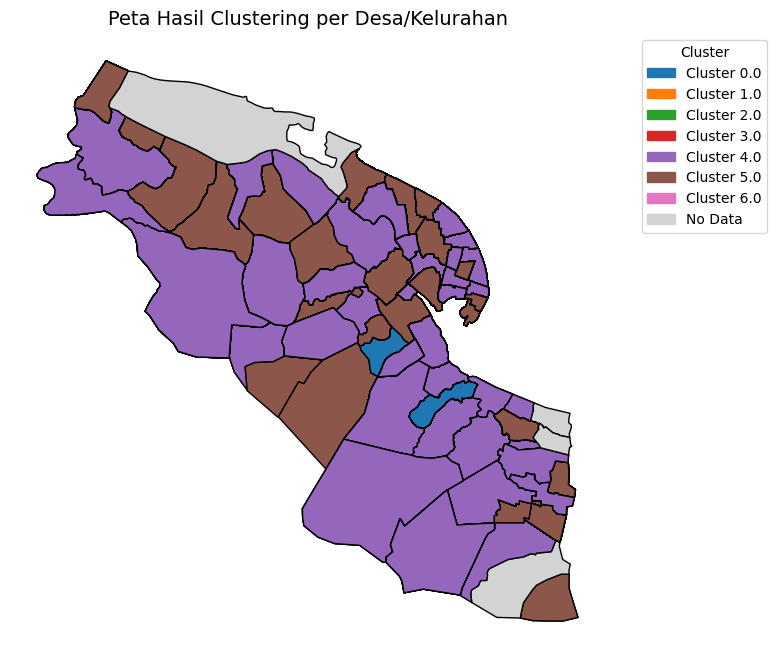

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# =============================
# 0. Baca data cluster
# =============================
data1 = pd.read_excel("Data_UMKM_Clustered_Modified.xlsx")  # Pastikan ada kolom 'Desa' dan 'cluster_mod'

# =============================
# 1. Baca shapefile
# =============================
gdf1 = gpd.read_file("zip://LSM.zip")

# =============================
# 2. Samakan format nama desa agar konsisten
# =============================
gdf1["DESA"] = gdf1["DESA"].str.strip().str.upper()
data1["Desa"] = data1["Desa"].str.strip().str.upper()

# =============================
# 3. Merge shapefile dengan data cluster
# =============================
gdf_merged1 = gdf1.merge(data1, how="left", left_on="DESA", right_on="Desa", indicator=True)

# =============================
# 4. Info jumlah data
# =============================
print("Jumlah baris shapefile:", len(gdf1))
print("Jumlah baris Excel:", len(data1))
print("Jumlah hasil merge (punya cluster):", gdf_merged1["cluster_mod"].notna().sum())

# =============================
# 4a. Tampilkan baris shapefile yang cluster_mod-nya NaN
# =============================
nan_rows = gdf_merged1[gdf_merged1["cluster_mod"].isna()]
print("\nBaris shapefile yang cluster_mod-nya NaN:")
print(nan_rows[["DESA", "cluster_mod"]])

# =============================
# 4b. Tampilkan baris Excel yang tidak ter-merge ke shapefile
# =============================
excel_not_merged = data1[~data1["Desa"].isin(gdf1["DESA"])]
print("\nBaris Excel yang tidak ter-merge ke shapefile:")
print(excel_not_merged)

# =============================
# 4c. Simpan hasil ke Excel
# =============================
with pd.ExcelWriter("hasil_merge.xlsx") as writer:
    nan_rows[["DESA", "cluster_mod"]].to_excel(writer, sheet_name="Shapefile_NaN", index=False)
    excel_not_merged.to_excel(writer, sheet_name="Excel_Not_Merged", index=False)

print("\nHasil desa yang tidak merge telah disimpan ke 'hasil_merge.xlsx'")

# =============================
# 5. Pastikan cluster_mod bertipe kategori
# =============================
gdf_merged1["cluster_mod"] = gdf_merged1["cluster_mod"].astype("category")

# =============================
# 6. Buat kolom warna (string biasa, bukan kategori)
# =============================
unique_clusters = gdf_merged1["cluster_mod"].cat.categories
colors = list(mcolors.TABLEAU_COLORS.values())
color_map = {cluster: colors[i % len(colors)] for i, cluster in enumerate(unique_clusters)}

gdf_merged1["color"] = gdf_merged1["cluster_mod"].map(color_map)
gdf_merged1["color"] = gdf_merged1["color"].astype(object)
gdf_merged1["color"] = gdf_merged1["color"].fillna("lightgrey")  # default untuk NaN

# =============================
# 7. Plot peta
# =============================
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf_merged1.plot(
    color=gdf_merged1["color"],
    edgecolor="black",
    ax=ax
)

# =============================
# 8. Buat legend manual
# =============================
legend_patches = [mpatches.Patch(color=color_map[c], label=f"Cluster {c}") for c in unique_clusters]
legend_patches.append(mpatches.Patch(color="lightgrey", label="No Data"))
plt.legend(handles=legend_patches, title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# =============================
# 9. Tambahkan judul
# =============================
plt.title("Peta Hasil Clustering per Desa/Kelurahan", fontsize=14)
plt.axis("off")
plt.show()


<Axes: >

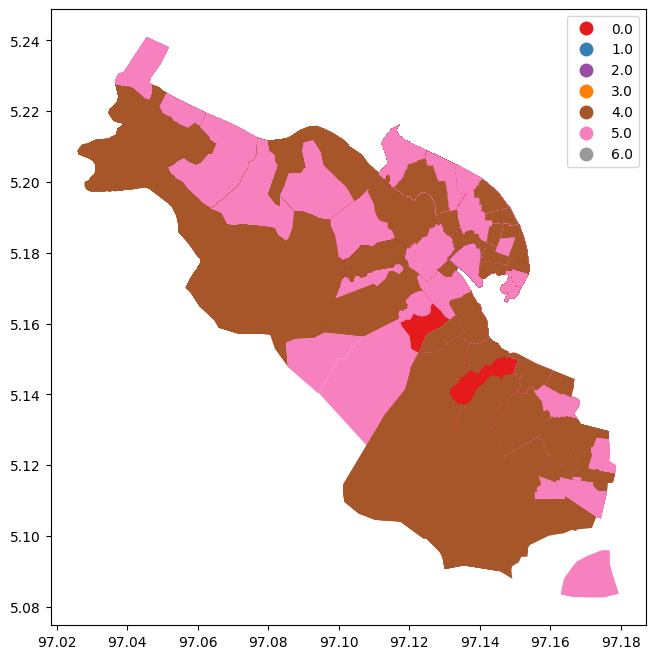

In [ ]:
gdf_merged1.plot(column="cluster_mod", cmap="Set1", legend=True, figsize=(12, 8))

In [ ]:
# Menampilkan data hanya untuk kecamatan tertentu, misalnya "BANDA SAKTI"
kecamatan_tertentu = "BLANG MANGAT"

# Filter GeoDataFrame
gdf_kecamatan = gdf1[gdf1["KECAMATAN"].str.upper() == kecamatan_tertentu]

# Lihat daftar desa di kecamatan tersebut
print(gdf_kecamatan[["DESA", "KECAMATAN"]])

# Hitung jumlah desa per kecamatan (hanya untuk kecamatan ini)
print(gdf_kecamatan[["DESA", "KECAMATAN"]].value_counts())


                DESA     KECAMATAN
0            TEUNGOH  BLANG MANGAT
1       MANE KAREUNG  BLANG MANGAT
14    MESJID MEURAYA  BLANG MANGAT
15    KEUDE PUNTEUET  BLANG MANGAT
16          JEULIKAT  BLANG MANGAT
17         SEUNEUBOK  BLANG MANGAT
23             BALOI  BLANG MANGAT
47             KUALA  BLANG MANGAT
48         BLANG CUT  BLANG MANGAT
49        JAMBO TIMU  BLANG MANGAT
50            TUNONG  BLANG MANGAT
51        BLANG TEUE  BLANG MANGAT
52      ASAN KAREUNG  BLANG MANGAT
53    RAYEUK KAREUNG  BLANG MANGAT
54    BLANG PUNTEUET  BLANG MANGAT
55  KUMBANG PUNTEUET  BLANG MANGAT
56   MESJID PUNTEUET  BLANG MANGAT
57   ULEE BLANG MANE  BLANG MANGAT
58          ALUE LIM  BLANG MANGAT
59       BLANG BULOH  BLANG MANGAT
60  BLANG WEU PANJOU  BLANG MANGAT
61   BLANG WEU BAROH  BLANG MANGAT
DESA              KECAMATAN   
ALUE LIM          BLANG MANGAT    1
ASAN KAREUNG      BLANG MANGAT    1
BALOI             BLANG MANGAT    1
BLANG BULOH       BLANG MANGAT    1
BLANG CUT         BL

Number of shapefile rows: 69
Number of Excel rows: 2748
Number of merged rows with cluster: 2748

Shapefile rows with NaN cluster_mod:
              DESA  cluster_mod
2542    JAMBO TIMU          NaN
2548    BLANG TEUE          NaN
2549  ASAN KAREUNG          NaN
2751   INDUSTRI???          NaN

Excel rows not merged into shapefile:
Empty DataFrame
Columns: [No, Sektor_Perdagangan, Mikro, Kecil, Menengah, Desa, Kecamatan, Jenis_Usaha, Tenaga_Kerja, Asset, Omzet, Jenis_Usaha_encoded, cluster_mod, cluster_std]
Index: []

Unmerged village results saved to 'merge_results.xlsx'


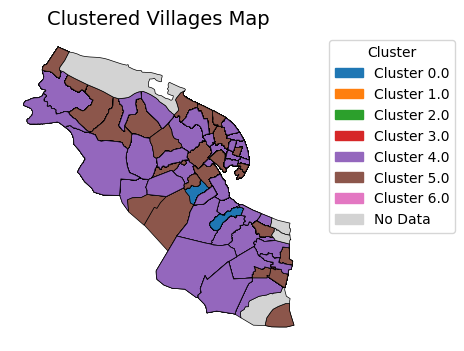

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# =============================
# 0. Read cluster data
# =============================
data = pd.read_excel("Data_UMKM_Clustered_Modified.xlsx")  # Columns: 'Desa', 'cluster_mod'

# =============================
# 1. Read shapefile
# =============================
gdf = gpd.read_file("zip://LSM.zip")

# =============================
# 2. Standardize village names
# =============================
gdf["DESA"] = gdf["DESA"].str.strip().str.upper()
data["Desa"] = data["Desa"].str.strip().str.upper()

# =============================
# 3. Merge shapefile with cluster data
# =============================
merged_gdf = gdf.merge(data, how="left", left_on="DESA", right_on="Desa", indicator=True)

# =============================
# 4. Data info
# =============================
print("Number of shapefile rows:", len(gdf))
print("Number of Excel rows:", len(data))
print("Number of merged rows with cluster:", merged_gdf["cluster_mod"].notna().sum())

# =============================
# 4a. Villages in shapefile without cluster
# =============================
nan_rows = merged_gdf[merged_gdf["cluster_mod"].isna()]
print("\nShapefile rows with NaN cluster_mod:")
print(nan_rows[["DESA", "cluster_mod"]])

# =============================
# 4b. Excel rows not merged
# =============================
excel_not_merged = data[~data["Desa"].isin(gdf["DESA"])]
print("\nExcel rows not merged into shapefile:")
print(excel_not_merged)

# =============================
# 4c. Save results to Excel
# =============================
with pd.ExcelWriter("merge_results.xlsx") as writer:
    nan_rows[["DESA", "cluster_mod"]].to_excel(writer, sheet_name="Shapefile_NaN", index=False)
    excel_not_merged.to_excel(writer, sheet_name="Excel_Not_Merged", index=False)

print("\nUnmerged village results saved to 'merge_results.xlsx'")

# =============================
# 5. Ensure cluster_mod is category type
# =============================
merged_gdf["cluster_mod"] = merged_gdf["cluster_mod"].astype("category")

# =============================
# 6. Create color column
# =============================
unique_clusters = list(merged_gdf["cluster_mod"].cat.categories)

# Ensure at least one color even if single cluster
if len(unique_clusters) == 0:
    unique_clusters = ["OnlyCluster"]

palette = list(mcolors.TABLEAU_COLORS.values())
if len(unique_clusters) > len(palette):
    palette = palette * ((len(unique_clusters) // len(palette)) + 1)

color_map = {cluster: palette[i] for i, cluster in enumerate(unique_clusters)}

# Map cluster to color and convert to object before filling NaN
merged_gdf["color"] = merged_gdf["cluster_mod"].map(color_map).astype(object)
merged_gdf["color"] = merged_gdf["color"].fillna("lightgrey")

# =============================
# 7. Plot map
# =============================
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot with black edge for contrast
merged_gdf.plot(
    color=merged_gdf["color"],
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# =============================
# 8. Legend
# =============================
legend_patches = [mpatches.Patch(color=color_map[c], label=f"Cluster {c}") for c in unique_clusters if c != "OnlyCluster"]
if merged_gdf["cluster_mod"].isna().any() or "OnlyCluster" in unique_clusters:
    legend_patches.append(mpatches.Patch(color="lightgrey", label="No Data"))

plt.legend(handles=legend_patches, title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# =============================
# 9. Title
# =============================
plt.title("Clustered Villages Map", fontsize=14)
plt.axis("off")
plt.show()


Excel rows not merged into shapefile:
Empty DataFrame
Columns: [Desa, cluster_mod]
Index: []

Shapefile rows with NaN cluster_mod:
              DESA  cluster_mod
2542    JAMBO TIMU          NaN
2548    BLANG TEUE          NaN
2549  ASAN KAREUNG          NaN
2751   INDUSTRI???          NaN


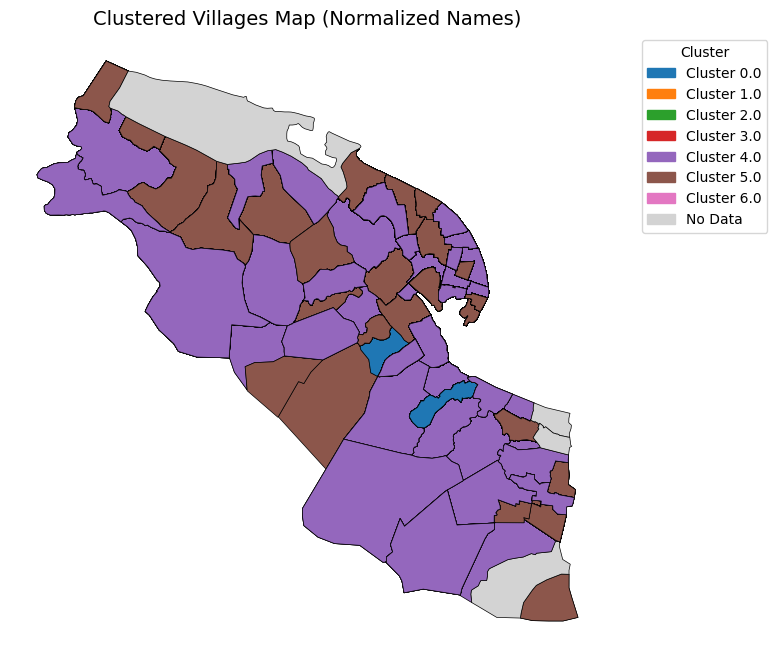

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import re

# =============================
# 0. Read cluster data
# =============================
data = pd.read_excel("Data_UMKM_Clustered_Modified.xlsx")  # Columns: 'Desa', 'cluster_mod'

# =============================
# 1. Read shapefile
# =============================
gdf = gpd.read_file("zip://LSM.zip")

# =============================
# 2. Function to normalize village names
# =============================
def normalize_name(name):
    if pd.isna(name):
        return ""
    name = str(name).upper()              # Huruf kapital
    name = re.sub(r'\s+', ' ', name)      # Hapus spasi ganda
    name = name.strip()                    # Hapus spasi awal/akhir
    name = re.sub(r'[^A-Z0-9 ]', '', name) # Hapus karakter khusus
    return name

gdf["DESA_NORM"] = gdf["DESA"].apply(normalize_name)
data["Desa_NORM"] = data["Desa"].apply(normalize_name)

# =============================
# 3. Merge shapefile with cluster data
# =============================
merged_gdf = gdf.merge(data, how="left", left_on="DESA_NORM", right_on="Desa_NORM", indicator=True)

# =============================
# 4. Show villages not merged
# =============================
excel_not_merged = data[~data["Desa_NORM"].isin(gdf["DESA_NORM"])]
nan_rows = merged_gdf[merged_gdf["cluster_mod"].isna()]

print("Excel rows not merged into shapefile:")
print(excel_not_merged[["Desa", "cluster_mod"]])

print("\nShapefile rows with NaN cluster_mod:")
print(nan_rows[["DESA", "cluster_mod"]])

# =============================
# 5. Ensure cluster_mod is category
# =============================
merged_gdf["cluster_mod"] = merged_gdf["cluster_mod"].astype("category")

# =============================
# 6. Assign colors
# =============================
unique_clusters = list(merged_gdf["cluster_mod"].cat.categories)
palette = list(mcolors.TABLEAU_COLORS.values())
if len(unique_clusters) > len(palette):
    palette = palette * ((len(unique_clusters)//len(palette))+1)

color_map = {cluster: palette[i] for i, cluster in enumerate(unique_clusters)}
merged_gdf["color"] = merged_gdf["cluster_mod"].map(color_map).astype(object)
merged_gdf["color"] = merged_gdf["color"].fillna("lightgrey")

# =============================
# 7. Plot map
# =============================
fig, ax = plt.subplots(1,1, figsize=(10,8))
merged_gdf.plot(color=merged_gdf["color"], edgecolor="black", linewidth=0.5, ax=ax)

legend_patches = [mpatches.Patch(color=color_map[c], label=f"Cluster {c}") for c in unique_clusters]
if merged_gdf["cluster_mod"].isna().any():
    legend_patches.append(mpatches.Patch(color="lightgrey", label="No Data"))

plt.legend(handles=legend_patches, title="Cluster", bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("Clustered Villages Map (Normalized Names)", fontsize=14)
plt.axis("off")
plt.show()


Jumlah baris shapefile: 69
Jumlah baris Excel: 2748
Jumlah hasil merge (punya cluster): 2748

Baris shapefile yang cluster_mod-nya NaN:
              DESA  cluster_mod
2542    JAMBO TIMU          NaN
2548    BLANG TEUE          NaN
2549  ASAN KAREUNG          NaN
2751   INDUSTRI???          NaN

Baris Excel yang tidak ter-merge ke shapefile:
Empty DataFrame
Columns: [No, Sektor_Perdagangan, Mikro, Kecil, Menengah, Desa, Kecamatan, Jenis_Usaha, Tenaga_Kerja, Asset, Omzet, Jenis_Usaha_encoded, cluster_mod, cluster_std]
Index: []

Hasil desa yang tidak merge dan hasil merge lengkap telah disimpan ke 'hasil_merge.xlsx'


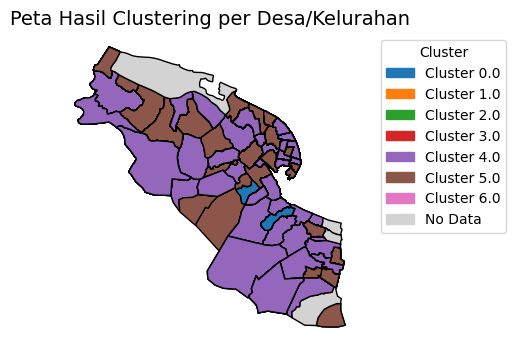

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# =============================
# 0. Baca data cluster
# =============================
data1 = pd.read_excel("Data_UMKM_Clustered_Modified.xlsx")  # Pastikan ada kolom 'Desa' dan 'cluster_mod'

# =============================
# 1. Baca shapefile
# =============================
gdf1 = gpd.read_file("zip://LSM.zip")

# =============================
# 2. Samakan format nama desa agar konsisten
# =============================
gdf1["DESA"] = gdf1["DESA"].str.strip().str.upper()
data1["Desa"] = data1["Desa"].str.strip().str.upper()

# =============================
# 3. Merge shapefile dengan data cluster
# =============================
gdf_merged1 = gdf1.merge(data1, how="left", left_on="DESA", right_on="Desa", indicator=True)

# =============================
# 4. Info jumlah data
# =============================
print("Jumlah baris shapefile:", len(gdf1))
print("Jumlah baris Excel:", len(data1))
print("Jumlah hasil merge (punya cluster):", gdf_merged1["cluster_mod"].notna().sum())

# =============================
# 4a. Tampilkan baris shapefile yang cluster_mod-nya NaN
# =============================
nan_rows = gdf_merged1[gdf_merged1["cluster_mod"].isna()]
print("\nBaris shapefile yang cluster_mod-nya NaN:")
print(nan_rows[["DESA", "cluster_mod"]])

# =============================
# 4b. Tampilkan baris Excel yang tidak ter-merge ke shapefile
# =============================
excel_not_merged = data1[~data1["Desa"].isin(gdf1["DESA"])]
print("\nBaris Excel yang tidak ter-merge ke shapefile:")
print(excel_not_merged)

# =============================
# 4c. Simpan hasil merge lengkap ke Excel
# =============================
with pd.ExcelWriter("hasil_merge.xlsx") as writer:
    # 1. Desa shapefile yang tidak punya cluster
    nan_rows[["DESA", "cluster_mod"]].to_excel(writer, sheet_name="Shapefile_NaN", index=False)
    # 2. Baris Excel yang tidak merge
    excel_not_merged.to_excel(writer, sheet_name="Excel_Not_Merged", index=False)
    # 3. Semua hasil merge lengkap
    gdf_merged1.to_excel(writer, sheet_name="Hasil_Merge_Lengkap", index=False)

print("\nHasil desa yang tidak merge dan hasil merge lengkap telah disimpan ke 'hasil_merge.xlsx'")

# =============================
# 5. Pastikan cluster_mod bertipe kategori
# =============================
gdf_merged1["cluster_mod"] = gdf_merged1["cluster_mod"].astype("category")

# =============================
# 6. Buat kolom warna (string biasa)
# =============================
unique_clusters = gdf_merged1["cluster_mod"].cat.categories
colors = list(mcolors.TABLEAU_COLORS.values())
color_map = {cluster: colors[i % len(colors)] for i, cluster in enumerate(unique_clusters)}

gdf_merged1["color"] = gdf_merged1["cluster_mod"].map(color_map)
gdf_merged1["color"] = gdf_merged1["color"].astype(object)
gdf_merged1["color"] = gdf_merged1["color"].fillna("lightgrey")  # default untuk NaN

# =============================
# 7. Plot peta
# =============================
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
gdf_merged1.plot(
    color=gdf_merged1["color"],
    edgecolor="black",
    ax=ax
)

# =============================
# 8. Buat legend manual
# =============================
legend_patches = [mpatches.Patch(color=color_map[c], label=f"Cluster {c}") for c in unique_clusters]
legend_patches.append(mpatches.Patch(color="lightgrey", label="No Data"))
plt.legend(handles=legend_patches, title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# =============================
# 9. Tambahkan judul
# =============================
plt.title("Peta Hasil Clustering per Desa/Kelurahan", fontsize=14)
plt.axis("off")
plt.show()


Jumlah baris shapefile: 69
Jumlah baris Excel: 2748
Jumlah hasil merge (punya cluster): 2748

Baris shapefile yang cluster_mod-nya NaN:
              DESA  cluster_mod
2542    JAMBO TIMU          NaN
2548    BLANG TEUE          NaN
2549  ASAN KAREUNG          NaN
2751   INDUSTRI???          NaN

Baris Excel yang tidak ter-merge ke shapefile:
Empty DataFrame
Columns: [No, Sektor_Perdagangan, Mikro, Kecil, Menengah, Desa, Kecamatan, Jenis_Usaha, Tenaga_Kerja, Asset, Omzet, Jenis_Usaha_encoded, cluster_mod, cluster_std]
Index: []


/tmp/ipython-input-4181574678.py:54: UserWarning: Geometry column does not contain geometry.
  gdf_merged_excel["geometry"] = gdf_merged_excel["geometry"].apply(lambda x: x.wkt if x else None)



Hasil desa yang tidak merge dan hasil merge lengkap telah disimpan ke 'hasil_merge.xlsx'


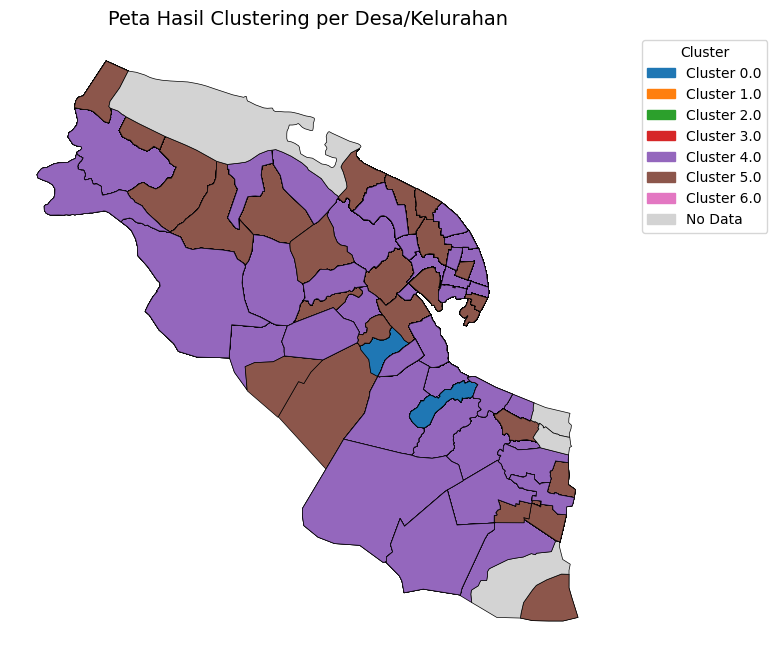

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from shapely import wkt

# =============================
# 0. Baca data cluster
# =============================
data1 = pd.read_excel("Data_UMKM_Clustered_Modified.xlsx")  # Kolom 'Desa' dan 'cluster_mod'

# =============================
# 1. Baca shapefile
# =============================
gdf1 = gpd.read_file("zip://LSM.zip")

# =============================
# 2. Standardisasi nama desa
# =============================
gdf1["DESA"] = gdf1["DESA"].str.strip().str.upper()
data1["Desa"] = data1["Desa"].str.strip().str.upper()

# =============================
# 3. Merge shapefile dengan data cluster
# =============================
gdf_merged1 = gdf1.merge(data1, how="left", left_on="DESA", right_on="Desa", indicator=True)

# =============================
# 4. Info jumlah data
# =============================
print("Jumlah baris shapefile:", len(gdf1))
print("Jumlah baris Excel:", len(data1))
print("Jumlah hasil merge (punya cluster):", gdf_merged1["cluster_mod"].notna().sum())

# =============================
# 4a. Tampilkan baris shapefile yang cluster_mod-nya NaN
# =============================
nan_rows = gdf_merged1[gdf_merged1["cluster_mod"].isna()]
print("\nBaris shapefile yang cluster_mod-nya NaN:")
print(nan_rows[["DESA", "cluster_mod"]])

# =============================
# 4b. Tampilkan baris Excel yang tidak ter-merge
# =============================
excel_not_merged = data1[~data1["Desa"].isin(gdf1["DESA"])]
print("\nBaris Excel yang tidak ter-merge ke shapefile:")
print(excel_not_merged)

# =============================
# 4c. Simpan hasil merge lengkap ke Excel (geometry dalam WKT)
# =============================
gdf_merged_excel = gdf_merged1.copy()
gdf_merged_excel["geometry"] = gdf_merged_excel["geometry"].apply(lambda x: x.wkt if x else None)

with pd.ExcelWriter("hasil_merge.xlsx") as writer:
    nan_rows[["DESA", "cluster_mod"]].to_excel(writer, sheet_name="Shapefile_NaN", index=False)
    excel_not_merged.to_excel(writer, sheet_name="Excel_Not_Merged", index=False)
    gdf_merged_excel.to_excel(writer, sheet_name="Hasil_Merge_Lengkap", index=False)

print("\nHasil desa yang tidak merge dan hasil merge lengkap telah disimpan ke 'hasil_merge.xlsx'")

# =============================
# 5. Pastikan cluster_mod bertipe kategori
# =============================
gdf_merged1["cluster_mod"] = gdf_merged1["cluster_mod"].astype("category")

# =============================
# 6. Buat kolom warna
# =============================
unique_clusters = gdf_merged1["cluster_mod"].cat.categories
colors = list(mcolors.TABLEAU_COLORS.values())
color_map = {cluster: colors[i % len(colors)] for i, cluster in enumerate(unique_clusters)}

gdf_merged1["color"] = gdf_merged1["cluster_mod"].map(color_map)
gdf_merged1["color"] = gdf_merged1["color"].astype(object)
gdf_merged1["color"] = gdf_merged1["color"].fillna("lightgrey")  # default untuk NaN

# =============================
# 7. Plot peta
# =============================
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf_merged1.plot(
    color=gdf_merged1["color"],
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# =============================
# 8. Legend manual
# =============================
legend_patches = [mpatches.Patch(color=color_map[c], label=f"Cluster {c}") for c in unique_clusters]
if gdf_merged1["cluster_mod"].isna().any():
    legend_patches.append(mpatches.Patch(color="lightgrey", label="No Data"))

plt.legend(handles=legend_patches, title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# =============================
# 9. Judul
# =============================
plt.title("Peta Hasil Clustering per Desa/Kelurahan", fontsize=14)
plt.axis("off")
plt.show()


In [ ]:
gdf_merged1['cluster_mod'].value_counts()

,count
cluster_mod,
0.0,1246
5.0,1039
4.0,418
1.0,27
6.0,9
2.0,8
3.0,1
